# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 24 - 2do bimestre 2026

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

In [107]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [108]:
pd.set_option("display.max_columns",None)

In [109]:
#Importamos set de entrenamiento
path = r'.\adult_train.csv'
df = pd.read_csv(path)

In [110]:
#Importamos set de entrenamiento
path = r'.\adult_val.csv'
df_val = pd.read_csv(path)

## Definición funciones

In [111]:
def plot_dist(label):
    marital_counts = df[label].value_counts()
    plt.figure(figsize=(14, 4))
    plt.bar(marital_counts.index, marital_counts)
    plt.title(f'Distribución "{label}" ')
    plt.xlabel(label)
    plt.ylabel('Count')
    plt.show()

In [112]:
def plot_cross(label1,label2):
    #distribución de "workclass" sobre "income"
    
    if label2=='income':
        cross = pd.crosstab(df[label1],df[label2]).sort_values(by=">50K",ascending=False)
    else:
        cross = pd.crosstab(df[label1],df[label2])
        
    print(cross)

    #generamos un heatmap para visualizar la crosstab
    plt.figure(figsize=(5, 5))
    sns.heatmap(cross, annot=True, cmap='coolwarm')
    plt.show()

    return cross

## EDA

In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30162 non-null  int64
 1   workclass       30162 non-null  str  
 2   education       30162 non-null  str  
 3   marital-status  30162 non-null  str  
 4   occupation      30162 non-null  str  
 5   relationship    30162 non-null  str  
 6   race            30162 non-null  str  
 7   sex             30162 non-null  str  
 8   capital-gain    30162 non-null  int64
 9   capital-loss    30162 non-null  int64
 10  hours-per-week  30162 non-null  int64
 11  skill-profile   30162 non-null  str  
 12  native-country  30162 non-null  str  
 13  income          30162 non-null  str  
dtypes: int64(4), str(10)
memory usage: 3.2 MB


Vemos que no tenemos valores nulos (NaN) en ninguna columna

<h2><b>Revisión de cardinalidad de las columnas categóricas

In [114]:
#verificación de valores únicos en variables categoricas
categorial_columns = df.select_dtypes(include=['object','str']).columns
numerical_columns = df.select_dtypes(include=[np.number]).columns

for column in categorial_columns:
    print(f"Tenemos {len((df[column].unique()))}    valores únicos en la columna    {column}")

Tenemos 7    valores únicos en la columna    workclass
Tenemos 16    valores únicos en la columna    education
Tenemos 7    valores únicos en la columna    marital-status
Tenemos 14    valores únicos en la columna    occupation
Tenemos 6    valores únicos en la columna    relationship
Tenemos 5    valores únicos en la columna    race
Tenemos 2    valores únicos en la columna    sex
Tenemos 80    valores únicos en la columna    skill-profile
Tenemos 41    valores únicos en la columna    native-country
Tenemos 2    valores únicos en la columna    income


<p>Observamos que las siguientes columnas serán consideradas de alta cardinalidad: 
    <ul>
        <li>education</li>
        <li>occupation</li>
        <li>skill-profile</li>
        <li>native-country</li>
    </ul>
</p>

<h2>Distribución del target

Como primer paso, revisaremos si el dataset se encuentra balanceado, respecto de nuestra variable target

<Axes: >

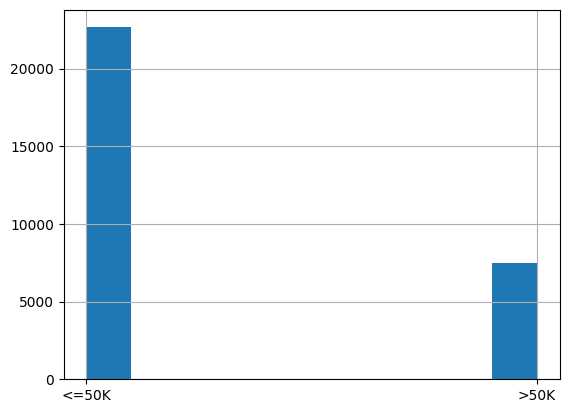

In [115]:
df["income"].hist()

Vemos que el dataset está claramente no balanceado, siendo que la mayoría de las muestras corresponden a la categoría "<=50K". <b>Se deberá tener un consideración al armar los dataset de validación y entrenamiento

Revisaremos los mismo, para ver la distribución del resto de nuestros features: 

<h2>Variable <b>workclass</b></h2>

In [116]:
#revisamos los valores unicos de workclass
df["workclass"].unique()

<StringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',     'Self-emp-inc',
      'Without-pay']
Length: 7, dtype: str

<p>Revisamos la distribución de "workclass"</p>

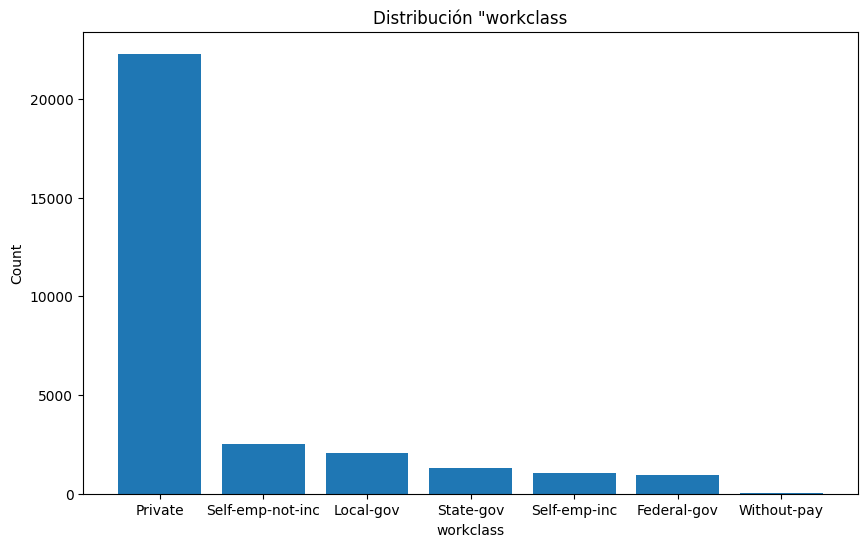

In [117]:
workclass_counts = df['workclass'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(workclass_counts.index, workclass_counts)
plt.title('Distribución "workclass')
plt.xlabel('workclass')
plt.ylabel('Count')
plt.show()

income            <=50K  >50K
workclass                    
Private           17410  4876
Self-emp-not-inc   1785   714
Local-gov          1458   609
Self-emp-inc        474   600
Federal-gov         578   365
State-gov           935   344
Without-pay          14     0


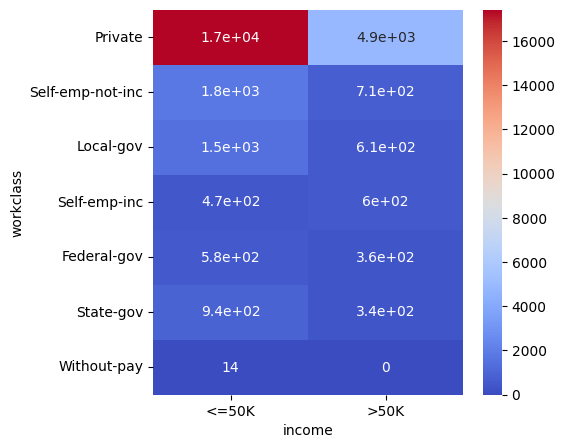

In [118]:
#distribución de "workclass" sobre "income"
cross = pd.crosstab(df["workclass"],df["income"]).sort_values(by=">50K",ascending=False)
print(cross)

#generamos un heatmap para visualizar la crosstab
plt.figure(figsize=(5, 5))
sns.heatmap(cross, annot=True, cmap='coolwarm')
plt.show()

<p>Vemos que la gran mayoría de nuestros casos correponden a trabajo en el sector privado. Como ya habíamos anticipado, la gran mayoría de muestras se encuentran dentro de la categoría "<=50K". </p>

<p>Hay un sólo caso llamativo: la categoría "State-gov" posee más registros que "Self-emp-inc" y "Federal-gov" en general, pero aporta menos a "income" = <=50K". Es decir: la categoría "State-gov" ganas en general menos que trabajar en el gobierno federal o ser "self employed"

<p><b>"Workclass"</b> es una variable categórica de siete valores únicos, en los que no podemos detectar un orden específico entre las categorías, por lo cuál, se opta por realizar un tipo de codificación "One-Hot-Encoding"

In [119]:
#OHE para columna "workclass"
encoded_workclass = pd.get_dummies(df["workclass"]).astype(int) #generación de la codificación one hot
encoded_workclass.drop(columns="Without-pay",inplace=True)      #drop de una de las columnas codificadas
df = pd.concat([df,encoded_workclass],axis=1)                   #axis: 1 = columna | 0 = fila
df.drop(columns="workclass",inplace=True)                       #drop columna original 
df.head(10)

,age,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income,Federal-gov,Local-gov,Private,Self-emp-inc,Self-emp-not-inc,State-gov
0,39,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K,0,0,0,0,0,1
1,50,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K,0,0,0,0,1,0
2,38,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K,0,0,1,0,0,0
3,53,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K,0,0,1,0,0,0
4,28,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K,0,0,1,0,0,0
5,37,Masters,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,personal_care_assistance,United-States,<=50K,0,0,1,0,0,0
6,49,9th,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,food_service_kitchen_basic,Jamaica,<=50K,0,0,1,0,0,0
7,52,HS-grad,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,transport_commercial_driving,United-States,>50K,0,0,0,0,1,0
8,31,Masters,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,tech_software_engineering,United-States,>50K,0,0,1,0,0,0
9,42,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,consulting_process_improvement,United-States,>50K,0,0,1,0,0,0


In [120]:
#OHE para columna "workclass" de DataFrame de validación
encoded_workclass = pd.get_dummies(df_val["workclass"]).astype(int) #generación de la codificación one hot
encoded_workclass.drop(columns="Without-pay",inplace=True)      #drop de una de las columnas codificadas
df_val = pd.concat([df_val,encoded_workclass],axis=1)                   #axis: 1 = columna | 0 = fila
df_val.drop(columns="workclass",inplace=True)                       #drop columna original 

<h2>Variable <b>relationship</b></h2>

In [121]:
df["relationship"].unique()

<StringArray>
['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried',
 'Other-relative']
Length: 6, dtype: str

In [122]:
df.groupby(by=["marital-status"],as_index=False)["relationship"].unique()

,marital-status,relationship
0,Divorced,"[Not-in-family, Unmarried, Own-child, Other-re..."
1,Married-AF-spouse,"[Wife, Husband, Own-child, Other-relative]"
2,Married-civ-spouse,"[Husband, Wife, Own-child, Other-relative, Not..."
3,Married-spouse-absent,"[Not-in-family, Unmarried, Own-child, Other-re..."
4,Never-married,"[Not-in-family, Own-child, Unmarried, Other-re..."
5,Separated,"[Unmarried, Own-child, Other-relative, Not-in-..."
6,Widowed,"[Unmarried, Not-in-family, Own-child, Other-re..."


<p>¿Existe una correlación entre esta variable "relationship" y la variable "marital-status? ¿Son ambas necesarias? Podemos pensar en tres maneras de saberlo:<ul><li>Entrenar modelo con ambas columnas codificadas en one hot y luego comparar con un modelo en el que se elimina la columna "relationship"</li><li>Realizar una "crosstab" entre ambas columnas, y verificar si las relaciones entre ambas son "obvias" o "complementarias" sin aportar información</li><li>Realizar un análisis "multivariante" entre "income", "relationship" y "marital-status"</li> 


relationship           Husband  Not-in-family  Other-relative  Own-child  \
marital-status                                                             
Divorced                     0           2268             103        308   
Married-AF-spouse            9              0               1          1   
Married-civ-spouse       12454             14             118         83   
Married-spouse-absent        0            181              26         43   
Never-married                0           4448             548       3929   
Separated                    0            383              53         90   
Widowed                      0            432              40         12   

relationship           Unmarried  Wife  
marital-status                          
Divorced                    1535     0  
Married-AF-spouse              0    10  
Married-civ-spouse             0  1396  
Married-spouse-absent        120     0  
Never-married                801     0  
Separated                   

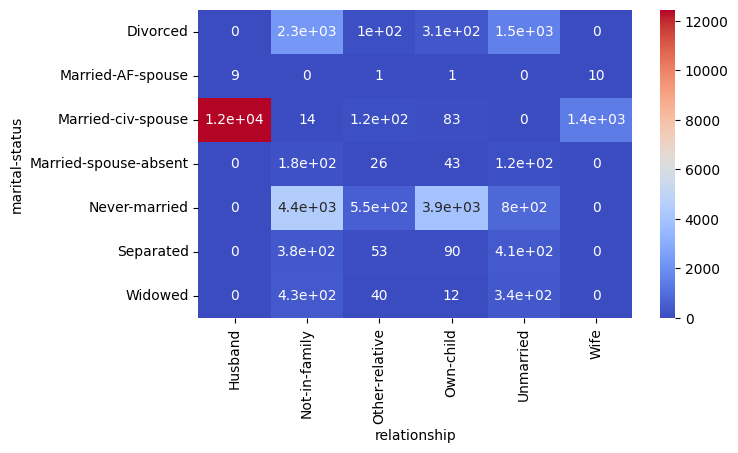

In [123]:
#distribución de "marital-status" sobre "relationship"
cross = pd.crosstab(df["marital-status"],df["relationship"])
print(cross)
#generamos un heatmap para visualizar la crosstab
plt.figure(figsize=(7, 4))
sns.heatmap(cross, annot=True, cmap='coolwarm')
plt.show()

<p>Si se presta atención al crosstab entre ambas variables, vemos que hay una relación lógica entre las categorías de ambas, siendo en la mayoría de los casos "relationship" una extensión o detalle de "marital-status". Para poder realizar una verificación fehaciente, restaría saber si este detalle extra que se agrega, realmente puede aportarnos mayor información sobre el "income". Como se mencionó anteriormente, existe un camino para poder determinar esta suposición: el entrenamiento de dos modelos y la comparación de sus métricas. Para el caso de este trabajo, conservaremos ambas columnas en principio</p>

<p>Al no existir una clara relación de orden lógica entre las categorías, utilizaremos una codificación One Hot

In [124]:
#OHE para columna "relationship"
encoded_relationship = pd.get_dummies(df["relationship"]).astype(int) #generación de la codificación one hot
encoded_relationship.drop(columns="Wife",inplace=True)      #drop de una de las columnas codificadas
df = pd.concat([df,encoded_relationship],axis=1)                   #axis: 1 = columna | 0 = fila
df.drop(columns="relationship",inplace=True)                       #drop columna original 
df.head(10)

,age,education,marital-status,occupation,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income,Federal-gov,Local-gov,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Husband,Not-in-family,Other-relative,Own-child,Unmarried
0,39,Bachelors,Never-married,Adm-clerical,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K,0,0,0,0,0,1,0,1,0,0,0
1,50,Bachelors,Married-civ-spouse,Exec-managerial,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K,0,0,0,0,1,0,1,0,0,0,0
2,38,HS-grad,Divorced,Handlers-cleaners,White,Male,0,0,40,agriculture_field_work,United-States,<=50K,0,0,1,0,0,0,0,1,0,0,0
3,53,11th,Married-civ-spouse,Handlers-cleaners,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K,0,0,1,0,0,0,1,0,0,0,0
4,28,Bachelors,Married-civ-spouse,Prof-specialty,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K,0,0,1,0,0,0,0,0,0,0,0
5,37,Masters,Married-civ-spouse,Exec-managerial,White,Female,0,0,40,personal_care_assistance,United-States,<=50K,0,0,1,0,0,0,0,0,0,0,0
6,49,9th,Married-spouse-absent,Other-service,Black,Female,0,0,16,food_service_kitchen_basic,Jamaica,<=50K,0,0,1,0,0,0,0,1,0,0,0
7,52,HS-grad,Married-civ-spouse,Exec-managerial,White,Male,0,0,45,transport_commercial_driving,United-States,>50K,0,0,0,0,1,0,1,0,0,0,0
8,31,Masters,Never-married,Prof-specialty,White,Female,14084,0,50,tech_software_engineering,United-States,>50K,0,0,1,0,0,0,0,1,0,0,0
9,42,Bachelors,Married-civ-spouse,Exec-managerial,White,Male,5178,0,40,consulting_process_improvement,United-States,>50K,0,0,1,0,0,0,1,0,0,0,0


In [125]:
#OHE para columna "relationship" para DataFrame de validación
encoded_relationship = pd.get_dummies(df_val["relationship"]).astype(int) #generación de la codificación one hot
encoded_relationship.drop(columns="Wife",inplace=True)      #drop de una de las columnas codificadas
df_val = pd.concat([df_val,encoded_relationship],axis=1)                   #axis: 1 = columna | 0 = fila
df_val.drop(columns="relationship",inplace=True)                       #drop columna original 

<h2>Variable <b>marital-status</b></h2>

In [126]:
df["marital-status"].unique()

<StringArray>
[        'Never-married',    'Married-civ-spouse',              'Divorced',
 'Married-spouse-absent',             'Separated',     'Married-AF-spouse',
               'Widowed']
Length: 7, dtype: str

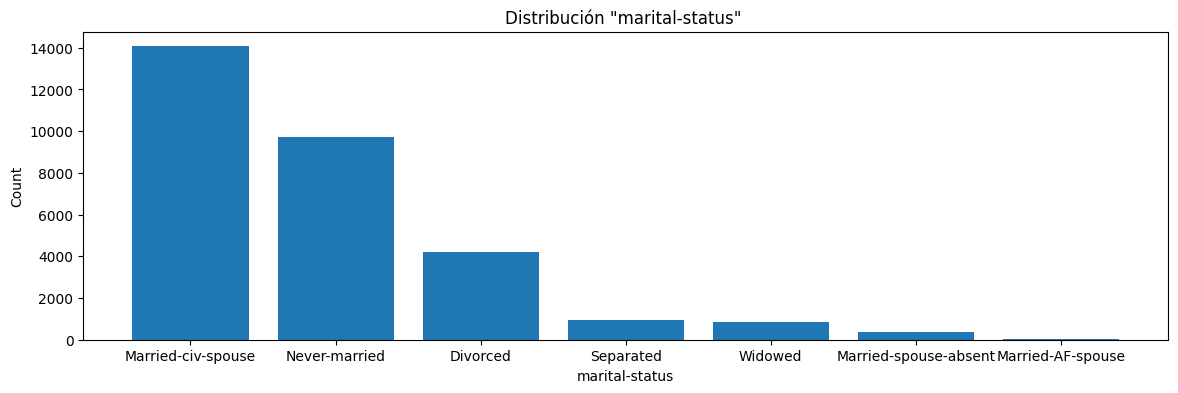

In [127]:
marital_counts = df['marital-status'].value_counts()

plt.figure(figsize=(14, 4))
plt.bar(marital_counts.index, marital_counts)
plt.title('Distribución "marital-status" ')
plt.xlabel('marital-status')
plt.ylabel('Count')
plt.show()

income                 <=50K  >50K
marital-status                    
Married-civ-spouse      7666  6399
Never-married           9256   470
Divorced                3762   452
Widowed                  747    80
Separated                873    66
Married-spouse-absent    339    31
Married-AF-spouse         11    10


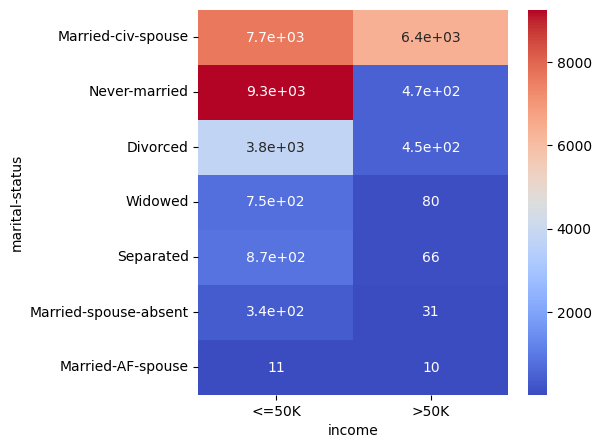

In [128]:
#distribución de "marital-status" sobre "income"
cross = pd.crosstab(df["marital-status"],df["income"]).sort_values(by=">50K",ascending=False)
print(cross)

#generamos un heatmap para visualizar la crosstab
plt.figure(figsize=(5, 5))
sns.heatmap(cross, annot=True, cmap='coolwarm')
plt.show()

<p>Vemos la gran diferencia que existe en la clase "Married-civ-spouse", donde la cantidad de registros en cada categoría de income no difieren de forma tan drástica como lo hacen en las demás. Por ejemplo, comparando con la siguiente categoría con "income>50K", vemos una gran diferencia de muestras y de balance de clase: sólo 4.83% de los "Never-married" poseen income alto, mientras que 45.45% de los casados poseen "income" alto. </p>
<p>Esto nos indica que saber si un registro pertenece a "Married-civ-spouse" puede ser un buen indicador sobre su "income", pero al tener un balance casi 50-50 dentro de la categoría misma, no nos es suficiente este dato por sí mismo: la red deberá suplirse de los demás datos para poder clasificar el caso

<p>Al igual que sucede con la columna workclass, vemos que las codificación más adecuada en la One-Hot</p>

In [129]:
#OHE para columna "marital-status"
encoded_marital_status = pd.get_dummies(df["marital-status"]).astype(int) #generación de la codificación one hot
encoded_marital_status.drop(columns="Widowed",inplace=True)      #drop de una de las columnas codificadas
df = pd.concat([df,encoded_marital_status],axis=1)                   #axis: 1 = columna | 0 = fila
df.drop(columns="marital-status",inplace=True)                       #drop columna original 
df.head(10)

,age,education,occupation,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income,Federal-gov,Local-gov,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated
0,39,Bachelors,Adm-clerical,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0
1,50,Bachelors,Exec-managerial,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0
2,38,HS-grad,Handlers-cleaners,White,Male,0,0,40,agriculture_field_work,United-States,<=50K,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0
3,53,11th,Handlers-cleaners,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0
4,28,Bachelors,Prof-specialty,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
5,37,Masters,Exec-managerial,White,Female,0,0,40,personal_care_assistance,United-States,<=50K,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
6,49,9th,Other-service,Black,Female,0,0,16,food_service_kitchen_basic,Jamaica,<=50K,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0
7,52,HS-grad,Exec-managerial,White,Male,0,0,45,transport_commercial_driving,United-States,>50K,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0
8,31,Masters,Prof-specialty,White,Female,14084,0,50,tech_software_engineering,United-States,>50K,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0
9,42,Bachelors,Exec-managerial,White,Male,5178,0,40,consulting_process_improvement,United-States,>50K,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0


In [130]:
#OHE para columna "marital-status"
encoded_marital_status = pd.get_dummies(df_val["marital-status"]).astype(int) #generación de la codificación one hot
encoded_marital_status.drop(columns="Widowed",inplace=True)      #drop de una de las columnas codificadas
df_val = pd.concat([df_val,encoded_marital_status],axis=1)                   #axis: 1 = columna | 0 = fila
df_val.drop(columns="marital-status",inplace=True)                       #drop columna original 


<h2>Variable <b>race</b></h2>

In [131]:
df["race"].unique()

<StringArray>
['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other']
Length: 5, dtype: str

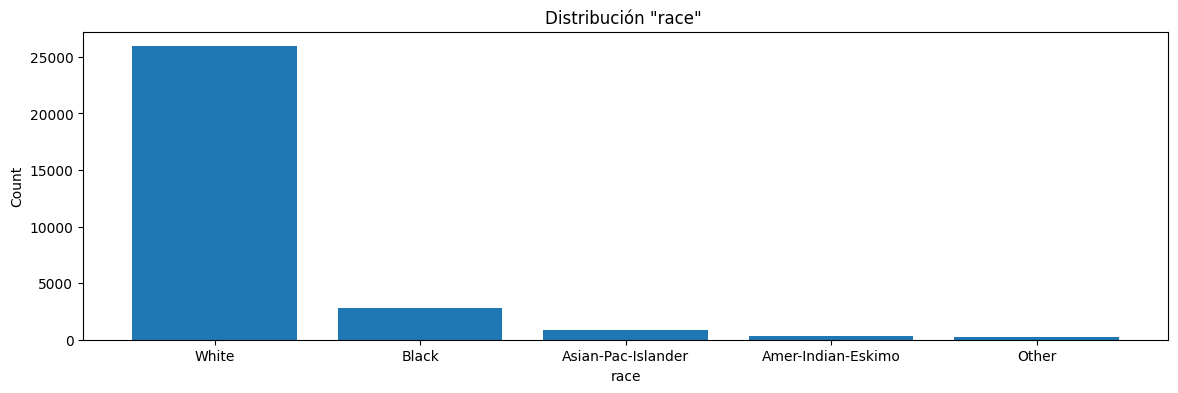

In [132]:
plot_dist('race')

income              <=50K  >50K
race                           
White               19094  6839
Black                2451   366
Asian-Pac-Islander    647   248
Amer-Indian-Eskimo    252    34
Other                 210    21


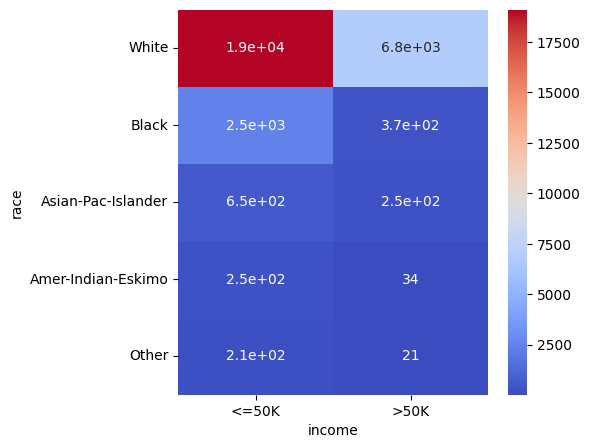

In [133]:
cross = plot_cross('race','income')

<p>Tenemos un desbalance dentro la categoría, ya que la gran mayoría de nuestras muestras, pertenecen a "white". Por lo cual el "crosstab" en valores abosolutos, no nos brinda demasiada información de cómo se relaciona la categoría con el "target". 
<p>Por esto, se procederá a revisar en porcentaje:

In [134]:
cross = pd.DataFrame(cross)
#se genera nueva columna con porcentaje de individuos de cada categoría con "income>50K"
cross["percentage_>50K"] = round(cross[">50K"]/(cross[">50K"]+cross["<=50K"])*100,2)
#se genera nueva columna con porcentaje de individuos de cada categoría con "income<=50K"
cross["percentage_<=50K"] = 100-round(cross[">50K"]/(cross[">50K"]+cross["<=50K"])*100,2)
cross.drop(columns=["<=50K",">50K"],inplace=True)
#Aplicamos un orden descendente según porcentaje con ingresos >50K
cross.sort_values(by="percentage_>50K",ascending=False)

income,percentage_>50K,percentage_<=50K
race,,
Asian-Pac-Islander,27.71,72.29
White,26.37,73.63
Black,12.99,87.01
Amer-Indian-Eskimo,11.89,88.11
Other,9.09,90.91


<p>De esta forma podemos ver una representación más adecuada de cómo se relaciona el ingreso con la etnia. La mayoría de los individuos de cada grupo, posee un "income" menor a 50K, pero sí vemos que pertenecear a ciertos grupos podría indicar "mayor probabilidad" de poseer más ingresos, en el orden en que lo vemos en la tabla. 

Sin embargo, esto no quiere decir que haya realmente una ordinalidad que podamos aplicar a la variable (de hacer esto, estaríamos asumiendo, por ejemplo, que el siguiente caso es válido: 1 = Amer-Indian-Esquimo | 2 = Black => 2*Amer-Indian-Esquimo = Black; lo cuál carece de sentido). Por ello, aplicamos OHE:

In [135]:
#OHE para columna "race"
encoded_race = pd.get_dummies(df["race"]).astype(int) #generación de la codificación one hot
encoded_race.drop(columns="Other",inplace=True)      #drop de una de las columnas codificadas
df = pd.concat([df,encoded_race],axis=1)                   #axis: 1 = columna | 0 = fila
df.drop(columns="race",inplace=True)                       #drop columna original 
df.head(10)

,age,education,occupation,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income,Federal-gov,Local-gov,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,White
0,39,Bachelors,Adm-clerical,Male,2174,0,40,manufacturing_assembly,United-States,<=50K,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1
1,50,Bachelors,Exec-managerial,Male,0,0,13,accounting_bookkeeping,United-States,<=50K,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
2,38,HS-grad,Handlers-cleaners,Male,0,0,40,agriculture_field_work,United-States,<=50K,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1
3,53,11th,Handlers-cleaners,Male,0,0,40,office_data_entry_basic,United-States,<=50K,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0
4,28,Bachelors,Prof-specialty,Female,0,0,40,tech_programming_advanced,Cuba,<=50K,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
5,37,Masters,Exec-managerial,Female,0,0,40,personal_care_assistance,United-States,<=50K,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
6,49,9th,Other-service,Female,0,0,16,food_service_kitchen_basic,Jamaica,<=50K,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0
7,52,HS-grad,Exec-managerial,Male,0,0,45,transport_commercial_driving,United-States,>50K,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
8,31,Masters,Prof-specialty,Female,14084,0,50,tech_software_engineering,United-States,>50K,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1
9,42,Bachelors,Exec-managerial,Male,5178,0,40,consulting_process_improvement,United-States,>50K,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1


In [136]:
#OHE para columna "race" para DataFrame de validación
encoded_race = pd.get_dummies(df_val["race"]).astype(int) #generación de la codificación one hot
encoded_race.drop(columns="Other",inplace=True)      #drop de una de las columnas codificadas
df_val = pd.concat([df_val,encoded_race],axis=1)                   #axis: 1 = columna | 0 = fila
df_val.drop(columns="race",inplace=True)                       #drop columna original 

<h2>Variable <b>sex</b></h2>

In [137]:
df["sex"].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

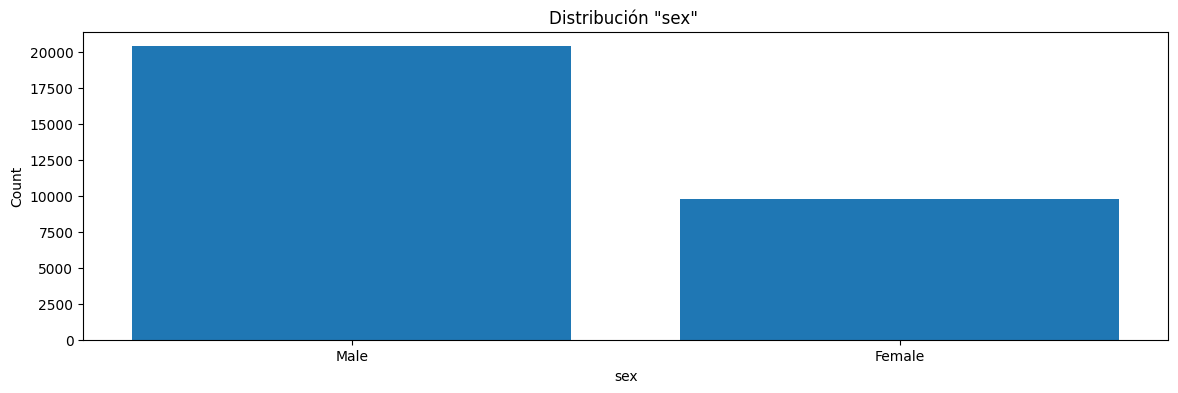

In [138]:
plot_dist('sex')

In [139]:
df['sex'].value_counts(normalize=True)*100

sex
Male      67.568464
Female    32.431536
Name: proportion, dtype: float64

Vemos que la gran mayoría de los casos, son hombres

income  <=50K  >50K
sex                
Male    13984  6396
Female   8670  1112


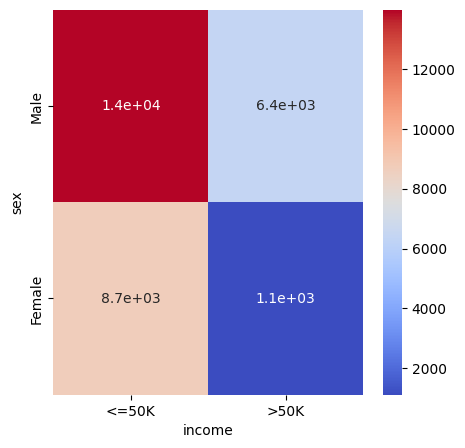

In [140]:
cross = plot_cross('sex','income')

In [141]:
cross = pd.DataFrame(cross)
#se genera nueva columna con porcentaje de individuos de cada categoría con "income>50K"
cross["percentage_>50K"] = round(cross[">50K"]/(cross[">50K"]+cross["<=50K"])*100,2)
#se genera nueva columna con porcentaje de individuos de cada categoría con "income<=50K"
cross["percentage_<=50K"] = 100-round(cross[">50K"]/(cross[">50K"]+cross["<=50K"])*100,2)
cross.drop(columns=["<=50K",">50K"],inplace=True)
#Aplicamos un orden descendente según porcentaje con ingresos >50K
cross.sort_values(by="percentage_>50K",ascending=False)

income,percentage_>50K,percentage_<=50K
sex,,
Male,31.38,68.62
Female,11.37,88.63


Vemos que existen proporcionalmente más hombres con "income>50K" que mujeres con "income>50K". Por lo tanto, nos resulta una variable útil para nuestro modelo

En este caso con una sola columa, podemos codificarlo con un label encoding: 

In [142]:
df["male"] = df["sex"]=="Male"
df["male"] = df["male"].astype(int)
df.drop(columns="sex",inplace=True)
df

,age,education,occupation,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income,Federal-gov,Local-gov,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,White,male
0,39,Bachelors,Adm-clerical,2174,0,40,manufacturing_assembly,United-States,<=50K,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1
1,50,Bachelors,Exec-managerial,0,0,13,accounting_bookkeeping,United-States,<=50K,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1
2,38,HS-grad,Handlers-cleaners,0,0,40,agriculture_field_work,United-States,<=50K,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,1
3,53,11th,Handlers-cleaners,0,0,40,office_data_entry_basic,United-States,<=50K,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1
4,28,Bachelors,Prof-specialty,0,0,40,tech_programming_advanced,Cuba,<=50K,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,27,Assoc-acdm,Tech-support,0,0,38,tech_programming_basic,United-States,<=50K,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
30158,40,HS-grad,Machine-op-inspct,0,0,40,trade_welding,United-States,>50K,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1
30159,58,HS-grad,Adm-clerical,0,0,40,trade_electrical,United-States,<=50K,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
30160,22,HS-grad,Adm-clerical,0,0,20,tech_computer_literacy,United-States,<=50K,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,1


In [143]:
df_val["male"] = df_val["sex"]=="Male"
df_val["male"] = df_val["male"].astype(int)
df_val.drop(columns="sex",inplace=True)

<h2>Variable <b>hours-per-week</b></h2>

Dado que "hours-per-week" es una variable numérica, veamos cómo se distribuye para cada clase de la categoría "income" 

<Figure size 1500x500 with 0 Axes>

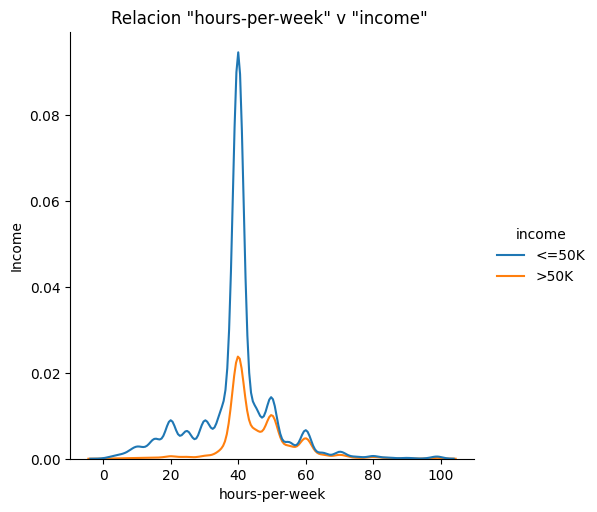

In [144]:
plt.figure(figsize=(15, 5))
sns.displot(data=df,x="hours-per-week",hue="income", kind="kde")
plt.title('Relacion "hours-per-week" v "income" ')
plt.xlabel('hours-per-week')
plt.ylabel('Income')
plt.show()

<p>Vemos que ambas distribuciones poseen un su máximo rondando las cuarenta horas semanales, y que sobrepasando ese valor, los siguientes máximos son casi idénticos.</p><p>Donde realmente difieren, es para los casos que trabajan menos de cuarenta horas, siendo que existen muy pocos casos con "income>50K" que se encuentren en esos valores. Es decir: trabajar más horas, no garantiza el mayor ingreso; pero trabajar menos horas, sí lo disminuye.


<h2>Variables <b>capital-gain</b> y <b>capital-loss</b></h2>

Se estudiará si las variables poseen relación entre ellas, con el fin de determinar si no podrían reemplazarse por un sólo feature "net-capital-outcome" (por ejemplo)

Veamos diez de estas columnas:

In [145]:
df[["capital-gain","capital-loss"]].head(10)

,capital-gain,capital-loss
0,2174,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,14084,0
9,5178,0


< (Menor que): Alt + 60
< (Menor que): Alt + 60

In [146]:
#revisamos si existen casos que posean información en ambas columnas
gain_and_loss = len(df[(df["capital-gain"]>0)&(df["capital-loss"]>0)])
print(f"Tenemos {gain_and_loss} registros con valores positivos tanto en gain como loss")

Tenemos 0 registros con valores positivos tanto en gain como loss


Vemos que los registros o poseen datos en una columna o en la otra, lo cuál podría ser un indicador de que es viable generar una nueva feature como la resta del gain y el loss para tener el resultado neto

In [147]:
gain_zero = len(df[(df["capital-gain"]==0)])
loss_zero = len(df[(df["capital-loss"]==0)])
print(f"{(gain_zero/len(df)*100):.2f} % de registros con valor 0 en 'capital-gain'.\n{(loss_zero/len(df)*100):.2f} % de registros con valor 0 en 'capital-loss'")

91.59 % de registros con valor 0 en 'capital-gain'.
95.27 % de registros con valor 0 en 'capital-loss'


Notar que casi la totalidad de estos registros poseen valor 0. Teniendo en cuenta esto y que ambos features son "excluyentes" se genera un nuevo feature:

In [148]:
df["capital-net-outcome"] = df["capital-gain"] - df["capital-loss"]

In [149]:
net_zero = len(df[(df["capital-net-outcome"]==0)])
print(f"{(net_zero/len(df)*100):.2f} % de registros con valor 0 en 'capital-gain'.")

86.85 % de registros con valor 0 en 'capital-gain'.


Si bien tenemos gran cantidad de registros con valor 0, disminuímos un poco su cantidad y reducimos el número de features de nuestro dataset.

In [150]:
df[["capital-gain","capital-loss"]].corr()

,capital-gain,capital-loss
capital-gain,1.000000,-0.032229
capital-loss,-0.032229,1.000000


Al no haber correlación entre sí, vemos que las columnas no son redundantes. Por lo tanto, necesitamos la información de ambas

In [151]:
df.drop(columns=["capital-gain","capital-loss"],inplace=True)

In [152]:
df_val["capital-net-outcome"] = df_val["capital-gain"] - df_val["capital-loss"]
df_val.drop(columns=["capital-gain","capital-loss"],inplace=True)

<h3>Las variables numéricas (age, capital-net-outcome y hours-per-week) serán normalizadas con un standar scaler</h3>

In [153]:
df.head()

,age,education,occupation,hours-per-week,skill-profile,native-country,income,Federal-gov,Local-gov,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,White,male,capital-net-outcome
0,39,Bachelors,Adm-clerical,40,manufacturing_assembly,United-States,<=50K,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,2174
1,50,Bachelors,Exec-managerial,13,accounting_bookkeeping,United-States,<=50K,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0
2,38,HS-grad,Handlers-cleaners,40,agriculture_field_work,United-States,<=50K,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0
3,53,11th,Handlers-cleaners,40,office_data_entry_basic,United-States,<=50K,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0
4,28,Bachelors,Prof-specialty,40,tech_programming_advanced,Cuba,<=50K,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0


<h2>Variables <b>education</b>, <b>occupation</b>, <b>skill-profile</b> y <b>native-country</b></h2>

<p>Para estas variables, dado su valor de cardinalidad (especificado al inicio de este análisis) se procederá a realizar una codificación mediante Embeddings

<p><b>Nota respecto a "Education":</b> si bien podríamos pensar que existe un orden lógico que nos permitiría aplicar a esta columna un "ordinal encoding", su alta cardinalidad (16 valores únicos) llevan a que se haya optado por utilizar un embedding para esta columna (según consigna, se considera alta cardinalidad más de 10 valores únicos)

<h2>Variable target</h2>

In [154]:
df["high_income"] = df["income"]==">50K"
df["high_income"] = df["high_income"].astype(int)
df.drop(columns="income",inplace=True)
df

,age,education,occupation,hours-per-week,skill-profile,native-country,Federal-gov,Local-gov,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,White,male,capital-net-outcome,high_income
0,39,Bachelors,Adm-clerical,40,manufacturing_assembly,United-States,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,2174,0
1,50,Bachelors,Exec-managerial,13,accounting_bookkeeping,United-States,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0
2,38,HS-grad,Handlers-cleaners,40,agriculture_field_work,United-States,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0
3,53,11th,Handlers-cleaners,40,office_data_entry_basic,United-States,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0
4,28,Bachelors,Prof-specialty,40,tech_programming_advanced,Cuba,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,27,Assoc-acdm,Tech-support,38,tech_programming_basic,United-States,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
30158,40,HS-grad,Machine-op-inspct,40,trade_welding,United-States,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,1
30159,58,HS-grad,Adm-clerical,40,trade_electrical,United-States,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
30160,22,HS-grad,Adm-clerical,20,tech_computer_literacy,United-States,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,1,0,0


In [155]:
df_val["high_income"] = df_val["income"]==">50K"
df_val["high_income"] = df_val["high_income"].astype(int)
df_val.drop(columns="income",inplace=True)

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

In [156]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

In [157]:
#normalizamos las columnas numércias de nuestro DataFrame: age, capital-net-outcome, hours-per-week
scaler = StandardScaler()
numerical_columns = ['age','hours-per-week','capital-net-outcome'] 
scaled_df = pd.DataFrame(scaler.fit_transform(df[numerical_columns]),columns=numerical_columns)
df.drop(columns=numerical_columns,inplace=True)
df = pd.concat([df,scaled_df],axis=1)
df

,education,occupation,skill-profile,native-country,Federal-gov,Local-gov,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,White,male,high_income,age,hours-per-week,capital-net-outcome
0,Bachelors,Adm-clerical,manufacturing_assembly,United-States,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0.042796,-0.077734,0.157514
1,Bachelors,Exec-managerial,accounting_bookkeeping,United-States,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0.880288,-2.331531,-0.135074
2,HS-grad,Handlers-cleaners,agriculture_field_work,United-States,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,-0.033340,-0.077734,-0.135074
3,11th,Handlers-cleaners,office_data_entry_basic,United-States,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1.108695,-0.077734,-0.135074
4,Bachelors,Prof-specialty,tech_programming_advanced,Cuba,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,-0.794697,-0.077734,-0.135074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,Assoc-acdm,Tech-support,tech_programming_basic,United-States,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,-0.870832,-0.244682,-0.135074
30158,HS-grad,Machine-op-inspct,trade_welding,United-States,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0.118931,-0.077734,-0.135074
30159,HS-grad,Adm-clerical,trade_electrical,United-States,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1.489374,-0.077734,-0.135074
30160,HS-grad,Adm-clerical,tech_computer_literacy,United-States,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,1,0,-1.251511,-1.747213,-0.135074


In [158]:
#normalizamos las columnas numércias de nuestro DataFrame: age, capital-net-outcome, hours-per-week (en este caso, sólo aplicamos "transform", ya realziamos el fit con los datos de train )
numerical_columns = ['age','hours-per-week','capital-net-outcome'] 
scaled_df_val = pd.DataFrame(scaler.transform(df_val[numerical_columns]),columns=numerical_columns)
df_val.drop(columns=numerical_columns,inplace=True)
df_val = pd.concat([df_val,scaled_df_val],axis=1)

<h2>Generación embeddings</h2>

<p>Como establecimos anteriormente, tenemos cuatro features a los cuales les aplicaremos embeddings: <ul>
<li>education</li>
<li>occupation</li>
<li>skill-profile</li>
<li>native-country</li>

In [159]:
#defino el tamaño y dimension de cada embeding
education_emb_size = len(df["education"].unique())
education_emb_dim = int(min(50,education_emb_size/2)) #regla empírica para menos de 50 categorías distinas (https://ai.stackexchange.com/questions/28564/how-to-determine-the-embedding-size)

occupation_emb_size = len(df["occupation"].unique())
occupation_emb_dim = int(min(50,occupation_emb_size/2)) #regla empírica para menos de 50 categorías distinas

skill_emb_size = len(df["skill-profile"].unique())
skill_emb_dim = int(min(50,skill_emb_size/2)) #regla empírica para menos de 50 categorías distinas

country_emb_size = len(df["native-country"].unique())
country_emb_dim = int(min(50,country_emb_size/2)) #regla empírica para menos de 50 categorías distinas

#defino los embeddings
education_emb = nn.Embedding(education_emb_size,education_emb_dim)
occupation_emb = nn.Embedding(occupation_emb_size,occupation_emb_dim)
skill_emb = nn.Embedding(skill_emb_size,skill_emb_dim)
country_emb = nn.Embedding(country_emb_size,country_emb_dim)

emb_columns = ["education",	"occupation",	"skill-profile", "native-country"]

<p>Dividimos DataFrame en X e y

In [160]:
X_train = df.drop(columns='high_income')
y_train = df["high_income"]
X_test = df_val.drop(columns='high_income')
y_test = df_val["high_income"]

In [161]:
df.columns

Index(['education', 'occupation', 'skill-profile', 'native-country',
       'Federal-gov', 'Local-gov', 'Private', 'Self-emp-inc',
       'Self-emp-not-inc', 'State-gov', 'Husband', 'Not-in-family',
       'Other-relative', 'Own-child', 'Unmarried', 'Divorced',
       'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent',
       'Never-married', 'Separated', 'Amer-Indian-Eskimo',
       'Asian-Pac-Islander', 'Black', 'White', 'male', 'high_income', 'age',
       'hours-per-week', 'capital-net-outcome'],
      dtype='str')

In [162]:
X_train.columns

Index(['education', 'occupation', 'skill-profile', 'native-country',
       'Federal-gov', 'Local-gov', 'Private', 'Self-emp-inc',
       'Self-emp-not-inc', 'State-gov', 'Husband', 'Not-in-family',
       'Other-relative', 'Own-child', 'Unmarried', 'Divorced',
       'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent',
       'Never-married', 'Separated', 'Amer-Indian-Eskimo',
       'Asian-Pac-Islander', 'Black', 'White', 'male', 'age', 'hours-per-week',
       'capital-net-outcome'],
      dtype='str')

In [163]:
#verifico si todas las columnas con embedding poseen todas sus categorias en ambos datasets
_ = 0
for column in emb_columns:
    for cat in X_train[column].unique():
        if len(X_test[X_test[column]==cat]) == 0:
            print(f"cat {cat} missin in column {column} in test")
            _+=1 
        
    for cat in X_test[column].unique():   
        if len(X_train[X_train[column]==cat]) == 0:
            print(f"cat {cat} missin in column {column} in train") 
            _+=1 

if _ == 0:
    print("Todas las categorias representadas en ambos datasets ")        

cat Holand-Netherlands missin in column native-country in test


Tenemos una categoría que falta en Test y para la cuál existe sólo un registro en Train. Verificamos:

In [164]:
#Verificamos que no exista sólo "Holand" o sólo "Neatherlands"
X_train["native-country"].sort_values().unique()

<StringArray>
[                  'Cambodia',                     'Canada',
                      'China',                   'Columbia',
                       'Cuba',         'Dominican-Republic',
                    'Ecuador',                'El-Salvador',
                    'England',                     'France',
                    'Germany',                     'Greece',
                  'Guatemala',                      'Haiti',
         'Holand-Netherlands',                   'Honduras',
                       'Hong',                    'Hungary',
                      'India',                       'Iran',
                    'Ireland',                      'Italy',
                    'Jamaica',                      'Japan',
                       'Laos',                     'Mexico',
                  'Nicaragua', 'Outlying-US(Guam-USVI-etc)',
                       'Peru',                'Philippines',
                     'Poland',                   'Portugal',
          

In [165]:
#Revisamos cantidad de registros de cada categoría
X_train.groupby(by="native-country").size().sort_values()

native-country
Holand-Netherlands                1
Scotland                         11
Honduras                         12
Hungary                          13
Outlying-US(Guam-USVI-etc)       14
Yugoslavia                       16
Laos                             17
Thailand                         17
Trinadad&Tobago                  18
Cambodia                         18
Hong                             19
Ireland                          24
France                           27
Ecuador                          27
Greece                           29
Peru                             30
Nicaragua                        33
Portugal                         34
Haiti                            42
Taiwan                           42
Iran                             42
Columbia                         56
Poland                           56
Japan                            59
Guatemala                        63
Vietnam                          64
Dominican-Republic               67
China        

<p>la única categoría para la cuál tenemos un solo registro es "Holand-Neatherlads". Al tener un sólo registro, aunque esté en el dataset de train y se agregue al diccionario lo más probable es que el embedding no podrá aprender un significado semántico singificativo</p>
</p>Revisando el total de la clase, vemos un fuerte desbalance (siendo "United-States" predominante). "Iran", con 42 apariciones, se encuentra en el centro del dataset. Una estrategia podría ser, definir como "Other" los casos que aparecen menos de 42 veces y agruparlos. Así, en vez de tener registros con categorías poco representada, tendríamos una categoría "Othet" que el embedding si podrá ajustar

In [166]:
#Almanceno el listado de paises y su cantidad de apariciones
value_counts = X_train.groupby(by="native-country").size().sort_values()

#Defino un valor de threshold
threshold = 42 

#Almaceno en una lista las categorías a renombrar como "Other"
rare_countries = value_counts[value_counts < threshold].index
rare_countries

#Modificación "CoW" (https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment)
X_train.loc[X_train["native-country"].isin(rare_countries), "native-country"] = "Other"
X_train[X_train["native-country"]=="Other"]

,education,occupation,skill-profile,native-country,Federal-gov,Local-gov,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,White,male,age,hours-per-week,capital-net-outcome
48,Prof-school,Prof-specialty,engineering_quality_assurance,Other,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.651881,1.591745,-0.391055
235,HS-grad,Farming-fishing,trade_electrical,Other,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0.271203,-0.077734,-0.135074
245,Some-college,Exec-managerial,sales_crm_basic,Other,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,-0.109476,2.843854,-0.135074
268,7th-8th,Craft-repair,agriculture_field_work,Other,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0.880288,-0.077734,-0.135074
282,Some-college,Adm-clerical,office_data_entry_basic,Other,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,-1.099239,-0.077734,-0.135074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29954,Bachelors,Prof-specialty,education_teaching_assistant,Other,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,-1.175375,1.174375,-0.135074
29968,HS-grad,Craft-repair,customer_service_retail,Other,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,-0.794697,-0.077734,-0.135074
29987,Bachelors,Exec-managerial,sales_account_management,Other,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0.804152,1.591745,-0.135074
30019,1st-4th,Machine-op-inspct,manufacturing_assembly,Other,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0.728017,-0.077734,-0.135074


In [167]:
#Almanceno el listado de paises y su cantidad de apariciones
value_counts = X_test.groupby(by="native-country").size().sort_values()

#Defino un valor de threshold
threshold = 42 

#Almaceno en una lista las categorías a renombrar como "Other"
rare_countries = value_counts[value_counts < threshold].index
rare_countries

#Modificación "CoW" (https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment)
X_test.loc[X_test["native-country"].isin(rare_countries), "native-country"] = "Other"

<p>Con este cambio, avanzamos con la creación de los tensores

In [168]:
from sklearn.preprocessing import LabelEncoder

In [169]:
X_train.select_dtypes(include=['object','str']).columns

Index(['education', 'occupation', 'skill-profile', 'native-country'], dtype='str')

In [ ]:
#verificamos si está disponible el GPU y si es así, para usarlo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Antes de convertir de "categórico" a "Embedding" se realiza un paso intermedio: "label encodig" (los ids son al azar)
categorial_columns = X_train.select_dtypes(include=['object','str']).columns
numerical_columns = X_train.select_dtypes(include=[np.number]).columns

for col in categorial_columns:
    label_enc = LabelEncoder()
    X_train[col] = label_enc.fit_transform(X_train[col])
    X_test[col] = label_enc.transform(X_test[col])

#necesitamos convertir nuestros DataFrame a tensores de Pytorch
X_train_edu = torch.tensor(X_train['education'].values, dtype=torch.long)
X_train_occ = torch.tensor(X_train['occupation'].values, dtype=torch.long)
X_train_skill = torch.tensor(X_train['skill-profile'].values, dtype=torch.long)
X_train_country = torch.tensor(X_train['native-country'].values, dtype=torch.long)
X_train_num = torch.tensor(X_train[numerical_columns].values, dtype=torch.float32)


X_test_edu = torch.tensor(X_test['education'].values, dtype=torch.long)
X_test_occ = torch.tensor(X_test['occupation'].values, dtype=torch.long)
X_test_skill = torch.tensor(X_test['skill-profile'].values, dtype=torch.long)
X_test_country = torch.tensor(X_test['native-country'].values, dtype=torch.long)
X_test_num = torch.tensor(X_test[numerical_columns].values, dtype=torch.float32)

y_train_tensor  = torch.tensor(y_train.to_numpy(),dtype=torch.float32)
y_test_tensor   = torch.tensor(y_test.to_numpy(),dtype=torch.float32)

education
occupation
skill-profile
native-country


<p>Habiendo explorado, codificado y finalmente convertido nuestro dataset ya divido a tensores, procedemos a definir el modelo

In [172]:
#defino tamaño de mi capa de entrada: features originales - features con emb + dimensiones embeddings
emb_columns = ["education",	"occupation",	"skill-profile", "native-country"]

input_size = X_train_num.shape[1] + education_emb_dim + occupation_emb_dim + skill_emb_dim + country_emb_dim
print(f"Tamaño capa de entrada = {input_size}")

Tamaño capa de entrada = 100


In [173]:
#Debemos definir una clase propia para nuestro modelo que herede de la clase "nn.Module"
#   Sobreescribimos el método forward que es llamado luego "internamente"
class Model(nn.Module):
    #
    #
    #   @fn:           __init__ 
    #   @brief:        declaramos todas las capas y características de nuestro modelo    
    #   @parameters:    
    #   
    def __init__(self,dropout_rate,input_size,education_embedding,occupation_embedding,skill_embedding,country_embedding):
        super().__init__() #debemos llamarlo porque estamos heredando de "nn.Module"
        self.dropout = nn.Dropout(dropout_rate)
        self.input_neurons = input_size

        self.education_emb = education_embedding
        self.occupation_emb = occupation_embedding
        self.skill_emb = skill_embedding
        self.country_emb = country_embedding
        #Inicializamos los pesos de los embedding con una distribución normal de desvío standar 0.01 (los valores, son aleatorios)
        nn.init.normal_(self.education_emb.weight, std=0.01)
        nn.init.normal_(self.occupation_emb.weight, std=0.01)
        nn.init.normal_(self.skill_emb.weight, std=0.01)
        nn.init.normal_(self.country_emb.weight, std=0.01)

        #defino la arquitectura del "multi layer perceptron"
        self.mlp = nn.Sequential(
            #Capa de entrada
            nn.Linear(self.input_neurons, 128),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            #capa oculta #1
            nn.Linear(128, 256),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            #capa oculta #2
            nn.Linear(256, 128),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            #capa oculta #3
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            #capa oculta #4
            nn.Linear(64, 32),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            #capa de salida
            nn.Linear(32, 1),
            )
        
    #
    #
    #   @fn:            forward
    #   @brief:         definimos cómo se usará el modelo definido en __init__
    #   @parameters:    
    #                    X_educations:  columa "education" de X
    #                    X_occupations: columa "occupation" de X
    #                    X_skills:      columa "skill" de X    
    #                    X_countries:   columa "native-country" de X
    #                    X_num:         columas numericas  de X    
    #
    def forward(self,X_educations,X_occupations,X_skills,X_countries,X_num):
        
        #cada columna pasa por su embedding categórica
        ee = self.education_emb(X_educations)
        oe = self.occupation_emb(X_occupations)
        se = self.skill_emb(X_skills)
        ce = self.country_emb(X_countries)

        #concatenamos nuevamentee todas nuestras columnas
        x = torch.cat([ee, oe,se,ce], dim=1)
        x = torch.cat([x,X_num], dim=1)

        #aplicamos un dropout inicial a nuestros datos (ponemos a 0 ciertos datos, entonces el modelo entrena sin ellos y lo forzamos a aprender otros patrones)
        # Es para prevenir overfitting
        x = self.dropout(x)
        #Aplicamos nuestro "multi layer perceptron" a nuestros datos
        out = self.mlp(x)
        #Convertimos la salida en un vector de una sola dimension (como suele ser "y", el ground truth)
        return out.squeeze(1)

Instanciamos el modelo, definimos optimizador y definimos función de pérdida 

In [174]:
#defini learning rate
lr = 0.001
#defino tamaño del batch a utilizar
batch_size = 512
#seteo número de épocas de entrenamiento
epochs = 50

#instancio mi modelo
model = Model(dropout_rate=0.3,
              input_size=input_size,
              country_embedding=country_emb,
              education_embedding=education_emb,
              skill_embedding=skill_emb,
              occupation_embedding=occupation_emb)
#paso a GPU
model = model.to(device)

#Usamos "Binary Cross Entropy Loss" ya que tenemos que clasificar entre exactamente dos clases
#bce_loss = nn.BCELoss()
bce_loss = nn.BCEWithLogitsLoss() #reemplazamos BCELoss() ya que este método incorpora una sigmoide que lleva los valores al rango 0-1 que requiere BCE


#Usaremos función de optimización tipo Adam
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

#Definimos nuestro dataset de train
train_ds = TensorDataset(X_train_edu, X_train_occ, X_train_skill, X_train_country, X_train_num,y_train_tensor)
#Definimos el DataLoader
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)

#Definimos nuestro dataset de test
test_ds = TensorDataset(X_test_edu, X_test_occ, X_test_skill, X_test_country, X_test_num,y_test_tensor)
#Definimos el DataLoader
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)
#NOTAR: en el loop de entreanmiento tenemos que "desempaquetar" en este mismo orden

<p>Implementamos el loop de entrenamiento

In [175]:
#defino listas para almacenar la evolución del loss
bce_train_his = []
bce_test_his  = []

f1_train_his = []
f1_test_his = []

acc_train_his = []
acc_test_his = []



for epoch in range(epochs+1):
    #seteamos modelo en modo entrenamiento (se habilita, por ejemplo, el dropout)
    model.train()

    batch_bce_train = []
    batch_f1_train = []
    train_preds = []
    train_targets = []

    #desempaquetamos nuestros datos
    for edu,occ,ski,cou,num,y in train_dl:
        #pasamos todo a GPU si está disponible
        edu = edu.to(device);occ = occ.to(device);cou = cou.to(device);ski = ski.to(device);num = num.to(device); y = y.to(device)

        #aplicamos nuestro modelo para obtener la predicción
        pred = model(edu,occ,ski,cou,num)

        #computamos el valor de la función de pérdida
        loss = bce_loss(pred,y)
        batch_bce_train.append((loss.item()))

        #Lógica de métricas
        # Transformo las predicciones devueltas por el modelo a probabilidades (rango 0 a 1)
        probs = torch.sigmoid(pred)
        #Si la probabilidad es > 0.5, es clase 1. Si no, es clase 0.
        classes = (probs > 0.5).int()
        #almaceno las clases predichas en el batch
        train_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
        #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
        train_targets.extend(y.cpu().numpy())

        #limpiamos los gradientes de batch anterior, para calcular luego en el paso backward los de esta iteración
        optimizer.zero_grad()
        #Realizamos el paso de backpropagation
        loss.backward()
        #Actualizamos los parámetros del modelo utilizando los gradientes calculados en el paso anterior
        optimizer.step()



    #guardo la pérdida BCE obtenida en esta época (como la media de la BCE de cada batch)
    bce_train_his.append(np.mean(batch_bce_train))
    #computyo el accuracy de train para la época
    acc_train_his.append(accuracy_score(train_targets,train_preds))
    #computo el f1 de train para la época
    f1_train_his.append(f1_score(train_targets,train_preds))

    #### Evaluación de modelo ####
    #Pasamos a eval
    model.eval()
    batch_bce_test = []
    batch_f1_test = []
    test_preds = []
    test_targets = []
    #desactivamos el cálculo de gradientes (utilizado en backpropagation). Esto ahorra recursos y tiempo
    with torch.no_grad():
        for edu,occ,ski,cou,num,y in test_dl:
            #pasamos todo a GPU si está disponible
            edu = edu.to(device);occ = occ.to(device);cou = cou.to(device);ski = ski.to(device);num = num.to(device);y = y.to(device)

            #aplicamos nuestro modelo para obtener la predicción
            pred = model(edu,occ,ski,cou,num)

            #computamos el valor de la función de pérdida
            loss = bce_loss(pred,y) 
            batch_bce_test.append(loss.item())

            #Lógica de métricas
            # Transformo las predicciones devueltas por el modelo a probabilidades (rango 0 a 1)
            probs = torch.sigmoid(pred)
            #Si la probabilidad es > 0.5, es clase 1. Si no, es clase 0.
            classes = (probs > 0.5).int()
            #almaceno las clases predichas en el batch
            test_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
            #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
            test_targets.extend(y.cpu().numpy())


        bce_test_his.append(np.mean(batch_bce_test))
        #computyo el accuracy de test para la época
        acc_test_his.append(accuracy_score(test_targets,test_preds))
        #computo el f1 de test para la época
        f1_test_his.append(f1_score(test_targets,test_preds))      



# Imprimir resumen de la época
    print(f"Epoch {epoch} | Train BCE: {bce_train_his[-1]:.4f} | Test BCE: {bce_test_his[-1]:.4f} | Test Acc: {acc_test_his[-1]:.4f} | Test F1: {f1_test_his[-1]:.4f}")


        



Epoch 0 | Train BCE: 0.5064 | Test BCE: 0.3272 | Test Acc: 0.8783 | Test F1: 0.7506
Epoch 1 | Train BCE: 0.3149 | Test BCE: 0.2688 | Test Acc: 0.8873 | Test F1: 0.7512
Epoch 2 | Train BCE: 0.2987 | Test BCE: 0.2674 | Test Acc: 0.8896 | Test F1: 0.7612
Epoch 3 | Train BCE: 0.2939 | Test BCE: 0.2630 | Test Acc: 0.8909 | Test F1: 0.7720
Epoch 4 | Train BCE: 0.2898 | Test BCE: 0.2636 | Test Acc: 0.8916 | Test F1: 0.7650
Epoch 5 | Train BCE: 0.2896 | Test BCE: 0.2629 | Test Acc: 0.8913 | Test F1: 0.7702
Epoch 6 | Train BCE: 0.2847 | Test BCE: 0.2595 | Test Acc: 0.8922 | Test F1: 0.7693
Epoch 7 | Train BCE: 0.2880 | Test BCE: 0.2602 | Test Acc: 0.8920 | Test F1: 0.7752
Epoch 8 | Train BCE: 0.2881 | Test BCE: 0.2596 | Test Acc: 0.8920 | Test F1: 0.7649
Epoch 9 | Train BCE: 0.2854 | Test BCE: 0.2594 | Test Acc: 0.8918 | Test F1: 0.7687
Epoch 10 | Train BCE: 0.2856 | Test BCE: 0.2579 | Test Acc: 0.8941 | Test F1: 0.7781
Epoch 11 | Train BCE: 0.2814 | Test BCE: 0.2594 | Test Acc: 0.8936 | Test F

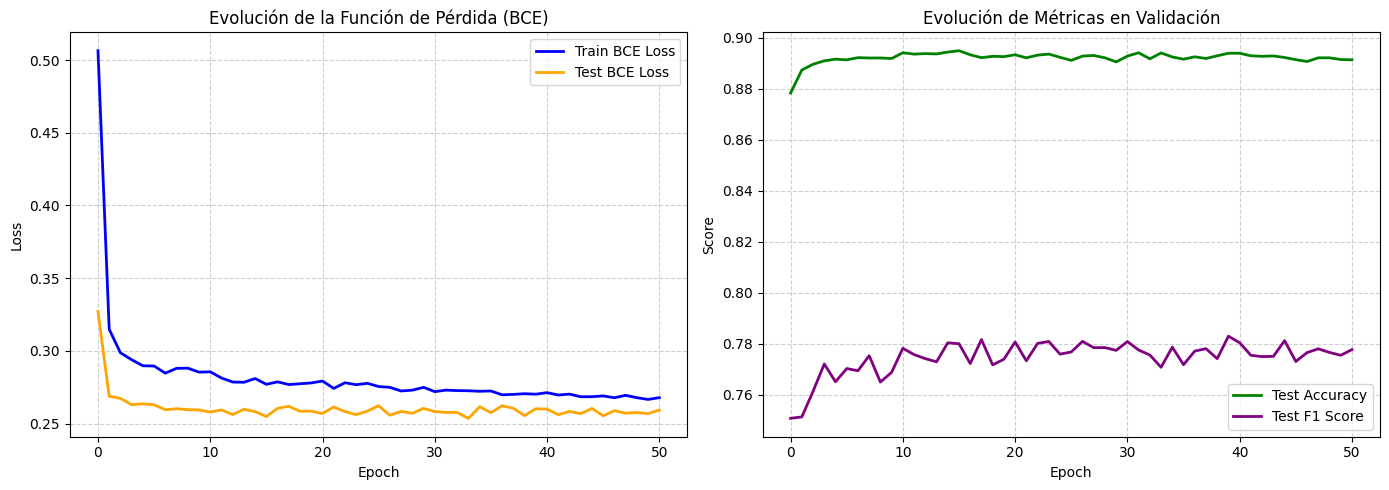

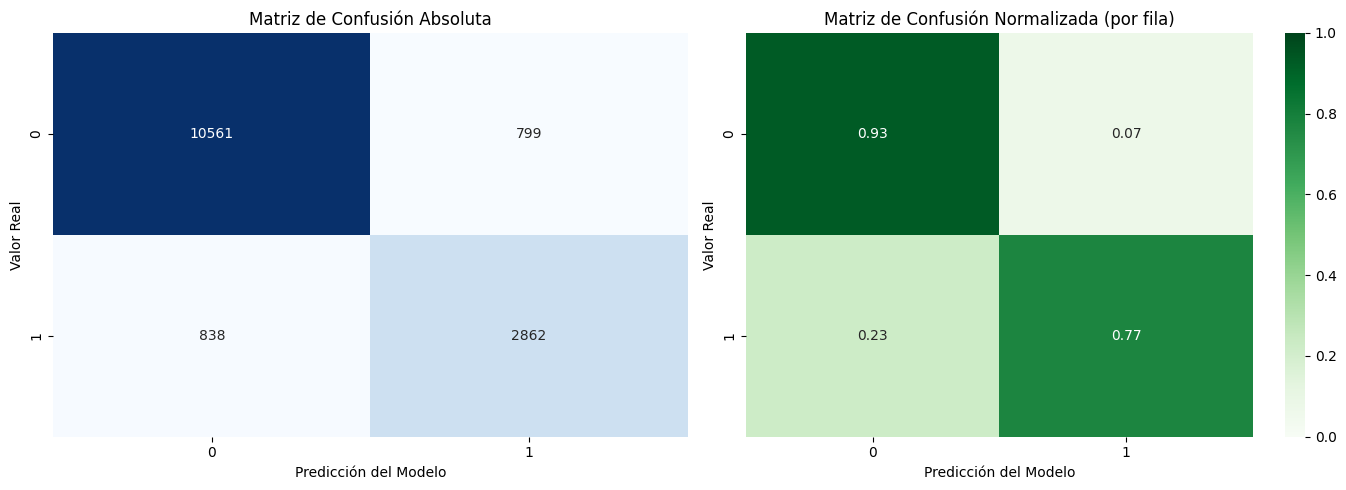

In [176]:
from sklearn.metrics import confusion_matrix

# Grafico curvas de función de pérdida de train y test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss (BCE)
ax1.plot(bce_train_his, label='Train BCE Loss', color='blue', linewidth=2)
ax1.plot(bce_test_his, label='Test BCE Loss', color='orange', linewidth=2)
ax1.set_title('Evolución de la Función de Pérdida (BCE)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico Accuracy y F1 Score
ax2.plot(acc_test_his, label='Test Accuracy', color='green', linewidth=2)
ax2.plot(f1_test_his, label='Test F1 Score', color='purple', linewidth=2)
ax2.set_title('Evolución de Métricas en Validación')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Genero las matrices de confusión
cm_absolute = confusion_matrix(test_targets, test_preds)
cm_normalized = confusion_matrix(test_targets, test_preds, normalize='true')

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_absolute, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False)
ax3.set_title('Matriz de Confusión Absoluta')
ax3.set_xlabel('Predicción del Modelo')
ax3.set_ylabel('Valor Real')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', ax=ax4, vmin=0, vmax=1)
ax4.set_title('Matriz de Confusión Normalizada (por fila)')
ax4.set_xlabel('Predicción del Modelo')
ax4.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

In [177]:
from sklearn.metrics import classification_report

# Generar reporte básico en texto
report = classification_report(test_targets, test_preds, target_names=['<=50K', '>50K'])
print(report)

              precision    recall  f1-score   support

       <=50K       0.93      0.93      0.93     11360
        >50K       0.78      0.77      0.78      3700

    accuracy                           0.89     15060
   macro avg       0.85      0.85      0.85     15060
weighted avg       0.89      0.89      0.89     15060



## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.

<p>Realizamos OHE para las variables que anteriormente fueron represantadas mediante embeddings

In [178]:
#OHE para columna "education"
encoded_education = pd.get_dummies(df["education"]).astype(int) #generación de la codificación one hot
encoded_education.drop(columns="Preschool",inplace=True)      #drop de una de las columnas codificadas
df = pd.concat([df,encoded_education],axis=1)                   #axis: 1 = columna | 0 = fila
df.drop(columns="education",inplace=True)                       #drop columna original 


#OHE para columna "occupation"
encoded_occupation = pd.get_dummies(df["occupation"]).astype(int) #generación de la codificación one hot
encoded_occupation.drop(columns="Armed-Forces",inplace=True)      #drop de una de las columnas codificadas
df = pd.concat([df,encoded_occupation],axis=1)                   #axis: 1 = columna | 0 = fila
df.drop(columns="occupation",inplace=True)                       #drop columna original 


#OHE para columna "skill-profile"
encoded_skill = pd.get_dummies(df["skill-profile"]).astype(int) #generación de la codificación one hot
encoded_skill.drop(columns="research_scientific_writing",inplace=True)      #drop de una de las columnas codificadas
df = pd.concat([df,encoded_skill],axis=1)                   #axis: 1 = columna | 0 = fila
df.drop(columns="skill-profile",inplace=True)                       #drop columna original 

#OHE para columna "native-country"
encoded_country = pd.get_dummies(df["native-country"]).astype(int) #generación de la codificación one hot
encoded_country.drop(columns="Holand-Netherlands",inplace=True)      #drop de una de las columnas codificadas
df = pd.concat([df,encoded_country],axis=1)                   #axis: 1 = columna | 0 = fila
df.drop(columns="native-country",inplace=True)                       #drop columna original 
df.head(5)

,Federal-gov,Local-gov,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,White,male,high_income,age,hours-per-week,capital-net-outcome,10th,11th,12th,1st-4th,5th-6th,7th-8th,9th,Assoc-acdm,Assoc-voc,Bachelors,Doctorate,HS-grad,Masters,Prof-school,Some-college,Adm-clerical,Craft-repair,Exec-managerial,Farming-fishing,Handlers-cleaners,Machine-op-inspct,Other-service,Priv-house-serv,Prof-specialty,Protective-serv,Sales,Tech-support,Transport-moving,accounting_bookkeeping,accounting_payroll,admin_document_control,admin_procurement_support,agriculture_field_work,automotive_repair,business_reporting_basic,caregiving_home_support,community_program_coordination,consulting_process_improvement,customer_service_hospitality,customer_service_retail,customer_success_operations,delivery_local_routes,education_classroom_teaching,education_curriculum_design,education_research_methods,education_teaching_assistant,engineering_drafting,engineering_quality_assurance,engineering_systems_design,entrepreneurship_business_development,entrepreneurship_small_business,executive_decision_support,facilities_maintenance,finance_budget_tracking,finance_financial_analysis,finance_investment_analysis,finance_risk_assessment,food_service_kitchen_basic,healthcare_clinical_coordination,healthcare_medical_assistant,healthcare_patient_support,healthcare_records_compliance,legal_case_management,legal_office_support,logistics_dispatch_coordination,logistics_forklift_operation,logistics_warehouse_basic,maintenance_janitorial,management_operations,management_people_operations,management_project_coordination,management_strategic_planning,management_team_lead,manufacturing_assembly,manufacturing_quality_control,office_data_entry_basic,office_records_management,office_spreadsheets_advanced,office_spreadsheets_basic,personal_care_assistance,protective_services_coordination,public_sector_administration,real_estate_sales_support,research_statistical_analysis,sales_account_management,sales_crm_advanced,sales_crm_basic,sales_retail_basic,security_patrol_basic,tech_cloud_systems,tech_computer_literacy,tech_cybersecurity,tech_data_analysis,tech_database_support,tech_network_support,tech_programming_advanced,tech_programming_basic,tech_software_engineering,tech_sql_reporting,tech_web_support,trade_cnc_operation,trade_construction_basic,trade_electrical,trade_machine_operation,trade_plumbing,trade_welding,transport_commercial_driving,Cambodia,Canada,China,Columbia,Cuba,Dominican-Republic,Ecuador,El-Salvador,England,France,Germany,Greece,Guatemala,Haiti,Honduras,Hong,Hungary,India,Iran,Ireland,Italy,Jamaica,Japan,Laos,Mexico,Nicaragua,Outlying-US(Guam-USVI-etc),Peru,Philippines,Poland,Portugal,Puerto-Rico,Scotland,South,Taiwan,Thailand,Trinadad&Tobago,United-States,Vietnam,Yugoslavia
0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0.042796,-0.077734,0.157514,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0.880288,-2.331531,-0.135074,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,-0.033340,-0.077734,-0.135074,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

<p>Generamos el train/test split y pase a tensores de nuestro nuevo dataset

In [179]:
X = df.drop(columns="high_income")
y = df["high_income"]
#Realizamos el split del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


#convert out dataframes to torch tensors
X_train_tensor = torch.tensor(X_train.to_numpy(),dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(),dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.to_numpy(),dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(),dtype=torch.float32)

#Split out dataset on Train and test
#X_train, X_test, y_train, y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)

#define number of input neurons
input_size = len(X.columns)
print(f"Tamaño de entrada {input_size}")


Tamaño de entrada 172


In [180]:
#Debemos definir una clase propia para nuestro modelo que herede de la clase "nn.Module"
#   Sobreescribimos el método forward que es llamado luego "internamente"
class Model_OHE(nn.Module):
    #
    #
    #   @fn:           __init__ 
    #   @brief:        declaramos todas las capas y características de nuestro modelo    
    #   @parameters:    
    #   
    def __init__(self,dropout_rate,input_size):
        super().__init__() #debemos llamarlo porque estamos heredando de "nn.Module"
        self.dropout = nn.Dropout(dropout_rate)
        self.input_neurons = input_size

        #defino la arquitectura del "multi layer perceptron"
        self.mlp = nn.Sequential(
            #Capa de entrada
            nn.Linear(self.input_neurons, 128),
            nn.LeakyReLU(),
            #capa oculta #1
            nn.Linear(128, 256),
            nn.LeakyReLU(),
            #capa oculta #2
            nn.Linear(256, 128),
            nn.LeakyReLU(),
            #capa oculta #3
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            #capa oculta #4
            nn.Linear(64, 32),
            nn.LeakyReLU(),
            #capa de salida
            nn.Linear(32, 1),
            )
        
    #
    #
    #   @fn:            forward
    #   @brief:         definimos cómo se usará el modelo definido en __init__
    #   @parameters:    
    #                    X_educations:  columa "education" de X
    #                    X_occupations: columa "occupation" de X
    #                    X_skills:      columa "skill" de X    
    #                    X_countries:   columa "native-country" de X
    #                    X_num:         columas numericas  de X    
    #
    def forward(self,x):
        
        #Aplicamos nuestro "multi layer perceptron" a nuestros datos
        out = self.mlp(x)
        #Convertimos la salida en un vector de una sola dimension (como suele ser "y", el ground truth)
        return out.squeeze(1)

In [181]:
#defini learning rate
lr = 0.001
#defino tamaño del batch a utilizar
batch_size = 512
#seteo número de épocas de entrenamiento
epochs = 50

#instancio mi modelo
model = Model_OHE(dropout_rate=0.3,
              input_size=input_size,
              )
#paso a GPU
model = model.to(device)

#Usamos "Binary Cross Entropy Loss" ya que tenemos que clasificar entre exactamente dos clases
#bce_loss = nn.BCELoss()
bce_loss = nn.BCEWithLogitsLoss() #reemplazamos BCELoss() ya que este método incorpora una sigmoide que lleva los valores al rango 0-1 que requiere BCE


#Usaremos función de optimización tipo Adam
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

#Definimos nuestro dataset de train
train_ds = TensorDataset(X_train_tensor,y_train_tensor)
#Definimos el DataLoader
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)

#Definimos nuestro dataset de test
test_ds = TensorDataset(X_test_tensor,y_test_tensor)
#Definimos el DataLoader
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

In [182]:
#defino listas para almacenar la evolución del loss
bce_train_his = []
bce_test_his  = []

f1_train_his = []
f1_test_his = []

acc_train_his = []
acc_test_his = []



for epoch in range(epochs+1):
    #seteamos modelo en modo entrenamiento (se habilita, por ejemplo, el dropout)
    model.train()

    batch_bce_train = []
    batch_f1_train = []
    train_preds = []
    train_targets = []

    #desempaquetamos nuestros datos
    for x,y in train_dl:
        #pasamos todo a GPU si está disponible
        x = x.to(device);y = y.to(device)

        #aplicamos nuestro modelo para obtener la predicción
        pred = model(x)

        #computamos el valor de la función de pérdida
        loss = bce_loss(pred,y)
        batch_bce_train.append((loss.item()))

        #Lógica de métricas
        # Transformo las predicciones devueltas por el modelo a probabilidades (rango 0 a 1)
        probs = torch.sigmoid(pred)
        #Si la probabilidad es > 0.5, es clase 1. Si no, es clase 0.
        classes = (probs > 0.5).int()
        #almaceno las clases predichas en el batch
        train_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
        #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
        train_targets.extend(y.cpu().numpy())

        #limpiamos los gradientes de batch anterior, para calcular luego en el paso backward los de esta iteración
        optimizer.zero_grad()
        #Realizamos el paso de backpropagation
        loss.backward()
        #Actualizamos los parámetros del modelo utilizando los gradientes calculados en el paso anterior
        optimizer.step()



    #guardo la pérdida BCE obtenida en esta época (como la media de la BCE de cada batch)
    bce_train_his.append(np.mean(batch_bce_train))
    #computyo el accuracy de train para la época
    acc_train_his.append(accuracy_score(train_targets,train_preds))
    #computo el f1 de train para la época
    f1_train_his.append(f1_score(train_targets,train_preds))

    #### Evaluación de modelo ####
    #Pasamos a eval
    model.eval()
    batch_bce_test = []
    batch_f1_test = []
    test_preds = []
    test_targets = []
    #desactivamos el cálculo de gradientes (utilizado en backpropagation). Esto ahorra recursos y tiempo
    with torch.no_grad():
        for x,y in test_dl:
            #pasamos todo a GPU si está disponible
            x = x.to(device); y = y.to(device)

            #aplicamos nuestro modelo para obtener la predicción
            pred = model(x)

            #computamos el valor de la función de pérdida
            loss = bce_loss(pred,y) 
            batch_bce_test.append(loss.item())

            #Lógica de métricas
            # Transformo las predicciones devueltas por el modelo a probabilidades (rango 0 a 1)
            probs = torch.sigmoid(pred)
            #Si la probabilidad es > 0.5, es clase 1. Si no, es clase 0.
            classes = (probs > 0.5).int()
            #almaceno las clases predichas en el batch
            test_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
            #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
            test_targets.extend(y.cpu().numpy())


        bce_test_his.append(np.mean(batch_bce_test))
        #computyo el accuracy de test para la época
        acc_test_his.append(accuracy_score(test_targets,test_preds))
        #computo el f1 de test para la época
        f1_test_his.append(f1_score(test_targets,test_preds))      



# Imprimir resumen de la época
    print(f"Epoch {epoch} | Train BCE: {bce_train_his[-1]:.4f} | Test BCE: {bce_test_his[-1]:.4f} | Test Acc: {acc_test_his[-1]:.4f} | Test F1: {f1_test_his[-1]:.4f}")


        



Epoch 0 | Train BCE: 0.4974 | Test BCE: 0.3320 | Test Acc: 0.8480 | Test F1: 0.7217
Epoch 1 | Train BCE: 0.2868 | Test BCE: 0.2660 | Test Acc: 0.8877 | Test F1: 0.7716
Epoch 2 | Train BCE: 0.2620 | Test BCE: 0.2615 | Test Acc: 0.8877 | Test F1: 0.7772
Epoch 3 | Train BCE: 0.2522 | Test BCE: 0.2564 | Test Acc: 0.8897 | Test F1: 0.7705
Epoch 4 | Train BCE: 0.2461 | Test BCE: 0.2576 | Test Acc: 0.8914 | Test F1: 0.7647
Epoch 5 | Train BCE: 0.2461 | Test BCE: 0.2564 | Test Acc: 0.8929 | Test F1: 0.7796
Epoch 6 | Train BCE: 0.2349 | Test BCE: 0.2604 | Test Acc: 0.8930 | Test F1: 0.7699
Epoch 7 | Train BCE: 0.2306 | Test BCE: 0.2653 | Test Acc: 0.8911 | Test F1: 0.7651
Epoch 8 | Train BCE: 0.2263 | Test BCE: 0.2702 | Test Acc: 0.8866 | Test F1: 0.7783
Epoch 9 | Train BCE: 0.2204 | Test BCE: 0.2648 | Test Acc: 0.8887 | Test F1: 0.7608
Epoch 10 | Train BCE: 0.2106 | Test BCE: 0.2696 | Test Acc: 0.8898 | Test F1: 0.7740
Epoch 11 | Train BCE: 0.2014 | Test BCE: 0.2769 | Test Acc: 0.8883 | Test F

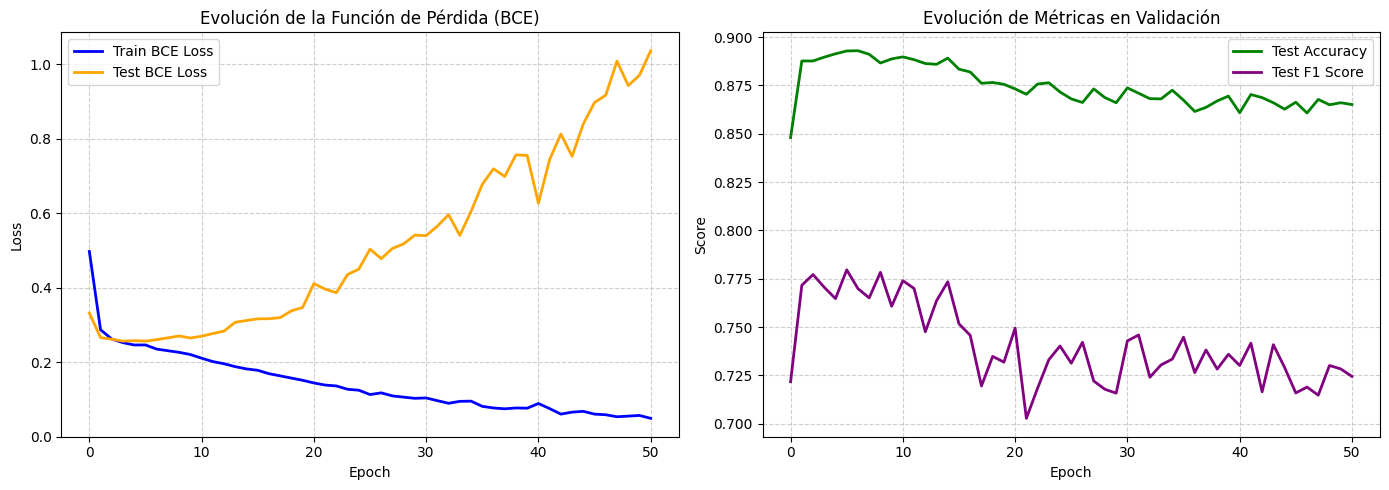

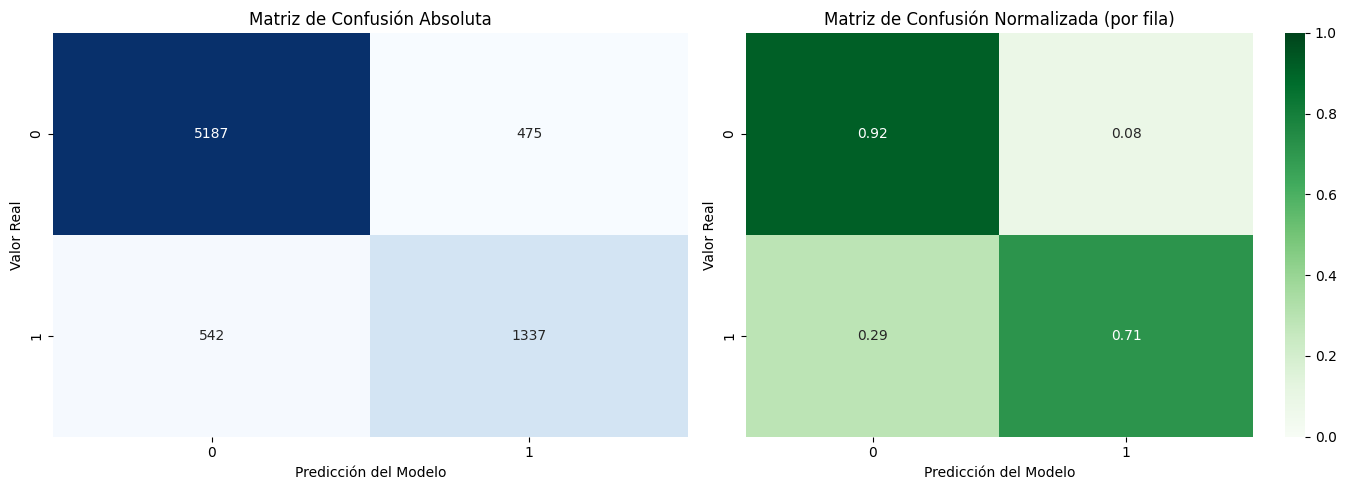

In [183]:
# Grafico curvas de función de pérdida de train y test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss (BCE)
ax1.plot(bce_train_his, label='Train BCE Loss', color='blue', linewidth=2)
ax1.plot(bce_test_his, label='Test BCE Loss', color='orange', linewidth=2)
ax1.set_title('Evolución de la Función de Pérdida (BCE)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico Accuracy y F1 Score
ax2.plot(acc_test_his, label='Test Accuracy', color='green', linewidth=2)
ax2.plot(f1_test_his, label='Test F1 Score', color='purple', linewidth=2)
ax2.set_title('Evolución de Métricas en Validación')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Genero las matrices de confusión
cm_absolute = confusion_matrix(test_targets, test_preds)
cm_normalized = confusion_matrix(test_targets, test_preds, normalize='true')

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_absolute, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False)
ax3.set_title('Matriz de Confusión Absoluta')
ax3.set_xlabel('Predicción del Modelo')
ax3.set_ylabel('Valor Real')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', ax=ax4, vmin=0, vmax=1)
ax4.set_title('Matriz de Confusión Normalizada (por fila)')
ax4.set_xlabel('Predicción del Modelo')
ax4.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

In [184]:
# Generar reporte
report = classification_report(test_targets, test_preds, target_names=['<=50K', '>50K'])
print(report)

              precision    recall  f1-score   support

       <=50K       0.91      0.92      0.91      5662
        >50K       0.74      0.71      0.72      1879

    accuracy                           0.87      7541
   macro avg       0.82      0.81      0.82      7541
weighted avg       0.86      0.87      0.86      7541



<p>Si observamos la evolución de la función de pérdida, notamos cómo de manera muy temprana (alrededor de la época 4) la curva de test comienza a crecer, en tanto la de train continúa disimuyendo hasta valores muy cercanos a 0 (0.0489). Lo que estamos observando, es que el modelo, en lugar de aprender los patrones presentes en los datos de entrenamiento, "memoriza" los datos produciendo <b>overfitting</b></p>
<p>Notar cómo el accuracy continúa siendo alto, y la matriz de confusión se ve correcta. En este caso, como hemos observado en la etapa de EDA, podemos atribuir esto a un alto desbalance en nuestra clase target</p>


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.

Tabla comparativa de modelos

| Modelo | Acc Test   | F1 Test | Inputs | Loss Train | Loss Test | 
| :--- | :---: |  :---: | :---: | :--- | :--- |
| **Emb + Dropout** | 0.8913 | 0.7776 | 104 | 0.2678 | 0.2594 |
| **OHE + No Droput** | 0.8651 | 0.7245 | 172 | 0.0489 | 1.0369 | 

<h3><b>Conclusiones</b></h3>

<p><ol type='a'><li> <b>Embeddings</b>: en cuanto a la utilización de los embeddings podemos obesrvar lo siguiente</li> 
        <ol type='i'>
            <li> Disminuyeron cantidad de nueronas de entrada de 172 en OHE a 104 con los embeddings (68 neuronas menos). Disminuyendo la dimensionalidad del problema </li>
            <li>Al capturar sentido semántico de cada palabra, puede asignarse un orden lógico a cada una, lo cuál ayuda (y ayudó en nuestro caso) a que el modelo pueda aprender más patrones presntes en los datos </li>
        </ol>
        <li> <b>Dropout</b>:</li> 
        <ol type='i'>
            <li> Al incluir dropout "forzamos" a que neuronas que (posiblemente) no se ajustaron en el Model_OHE, hayan en este caso trabajado durante el entrenamiento. De esta forma, evitamos el "sobre-entrenamiento" de algunas neuronas, y brindamos al modelo de capacidad de detectar más patrones en los datos</li>
            <li>Ayudó a evitar el overfitting, que sí podemos observar presente en el caso del Model_OHE.</li>
        </ol>
        <li> <b>Accuracy</b>:</li> 
        <ol type='i'>
            <li>Es imprortanto notar el desbalance en el target, esto provoca que si bien ambos modelos logran en accuracy alto sobre el test de validación, esta medida no sea representativa de la "calidad de predicción" lograda por el modelo</li>
        </ol>
        <li> <b>Matrices de confusión y f1 score</b>:</li> 
        <ol type='i'>
            <li>No vemos grandes diferencias entre los modelos. Este comportamiento, al igual que el del accuracy, puede atribuirse al desbalance del target. Que la matriz de confusión del "Modelo_OHE" sea similar a la del primer modelo, no indica que esté clasificando de manera correcta si no que, gracias al desbalance, su error se "enmascara". Una medida de esto, puede ser el <b>Recall del modelo</b>: cae de 0.77 (caso embedding+dropout) a 0.71 (caso OHE), indicándonos que el modelo pierde capacidad de "atrapar" los casos que verdaderamente poseen income alto, siendo la causa de la caída en el f1 score (de 0.77 a 0.72)</li>
        </ol>
    </ol>    
 </p>
<p>En conclusion, lo que podemos observar es la importancia e impacto en el ajuste del modelo de las capas de dropout (combaten overfitting y ayudan a apredizaje) y de la utilización de embeddings (ayudan a aprendizaje de variables categóricas, sobre todo de alta cardinaliad).</p>

